In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 1 : Imports + Connexion Contabo
# ============================================================
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
from sklearn.ensemble import IsolationForest
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Imports OK")
print(f"   XGBoost     : {xgb.__version__}")
print(f"   Pandas      : {pd.__version__}")
print(f"   Numpy       : {np.__version__}")

# ── Connexion ─────────────────────────────────────────────────
print("\nConnexion à Contabo...")

conn = psycopg2.connect(
    host     = '84.247.173.158',
    database = 'airflow',
    user     = 'ecotrack_2026',
    password = 'ecotrack_2026',
    port     = 5432,
    options  = "-c client_encoding=UTF8"
)
conn.set_client_encoding('UTF8')
cur = conn.cursor()

print("Chargement VW_ML_DATASET (768 000 lignes)...")
cur.execute('SELECT * FROM dw.vw_ml_dataset')
rows    = cur.fetchall()
columns = [desc[0] for desc in cur.description]
cur.close()
conn.close()

# ── DataFrame ─────────────────────────────────────────────────
df = pd.DataFrame(rows, columns=columns)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
df['date_bk']    = pd.to_datetime(df['date_bk'])
df['prev_date']  = pd.to_datetime(df['prev_date'])
df['is_weekend'] = df['is_weekend'].astype(bool)

print(f"\n{'='*55}")
print(f"  ECOTRACK v2 — DATASET CHARGÉ")
print(f"{'='*55}")
print(f"  Shape            : {df.shape}")
print(f"  Période          : {df['date_bk'].min().date()} → {df['date_bk'].max().date()}")
print(f"  Conteneurs       : {df['container_sk'].nunique():,}")
print(f"  Villes           : {df['city'].nunique()}")
print(f"  Types déchets    : {df['waste_type_name'].nunique()}")
print(f"  avg_fill         : {df['avg_fill'].mean():.2f}%")
print(f"  max_fill         : {df['max_fill'].max():.2f}%")
print(f"  Overflow 24h     : {df['will_overflow_24h'].mean()*100:.2f}%")
print(f"  NULL fill_j1     : {df['fill_j1'].isna().sum():,}")
print(f"  NULL target_j1   : {df['target_fill_j1'].isna().sum():,}")
print(f"{'='*55}")
print(f"\nColonnes disponibles ({len(df.columns)}) :")
print(list(df.columns))

✅ Imports OK
   XGBoost     : 3.2.0
   Pandas      : 2.2.2
   Numpy       : 2.0.2

Connexion à Contabo...
Chargement VW_ML_DATASET (768 000 lignes)...

  ECOTRACK v2 — DATASET CHARGÉ
  Shape            : (768000, 39)
  Période          : 2025-04-01 → 2026-04-19
  Conteneurs       : 2,000
  Villes           : 10
  Types déchets    : 9
  avg_fill         : 32.23%
  max_fill         : 100.00%
  Overflow 24h     : 8.71%
  NULL fill_j1     : 2,000
  NULL target_j1   : 2,000

Colonnes disponibles (39) :
['container_sk', 'container_bk', 'date_bk', 'prev_date', 'delta_days', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'zone_name', 'city', 'population', 'area_km2', 'latitude', 'longitude', 'container_type', 'capacity_l', 'waste_type_name', 'avg_fill', 'max_fill', 'min_fill', 'stddev_fill', 'overflow_count', 'avg_temp', 'avg_battery', 'avg_volume_litres', 'avg_poids_kg', 'nb_mesures', 'fill_j1', 'fill_j2', 'fill_j3', 'fill_j7', 'fill_trend_1j', 'fill_trend_7j', 'target_fill_j1', 'ta

In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 2 : EDA — Vue générale
# ============================================================

print("═"*55)
print("  CELLULE 2 — ANALYSE EXPLORATOIRE (EDA)")
print("═"*55)

# ── 2.1 Types et NULL ─────────────────────────────────────────
print("\n── 2.1 Types de données et valeurs manquantes ──")
null_summary = pd.DataFrame({
    'Type'    : df.dtypes,
    'Non-NULL': df.count(),
    'NULL'    : df.isna().sum(),
    'NULL %'  : (df.isna().sum() / len(df) * 100).round(2)
})
null_summary = null_summary[null_summary['NULL'] > 0]
if len(null_summary) == 0:
    print("  ✅ Aucune valeur manquante (hors fill_j1/target attendus)")
else:
    print(null_summary.to_string())

# ── 2.2 Statistiques descriptives features numériques ─────────
print("\n── 2.2 Statistiques descriptives ──")
num_cols = ['avg_fill','max_fill','min_fill','stddev_fill',
            'overflow_count','avg_temp','avg_battery',
            'avg_volume_litres','avg_poids_kg','nb_mesures',
            'fill_j1','fill_trend_1j','fill_trend_7j',
            'capacity_l','population','area_km2']
print(df[num_cols].describe().round(2).to_string())

# ── 2.3 Distribution par ville ────────────────────────────────
print("\n── 2.3 Distribution par ville ──")
ville_stats = df.groupby('city').agg(
    nb_conteneurs   = ('container_sk','nunique'),
    avg_fill        = ('avg_fill','mean'),
    taux_overflow   = ('will_overflow_24h','mean'),
    avg_battery     = ('avg_battery','mean')
).round(2).sort_values('avg_fill', ascending=False)
print(ville_stats.to_string())

# ── 2.4 Distribution par type de déchet ──────────────────────
print("\n── 2.4 Distribution par type de déchet ──")
dechet_stats = df.groupby('waste_type_name').agg(
    nb_conteneurs = ('container_sk','nunique'),
    avg_fill      = ('avg_fill','mean'),
    taux_overflow = ('will_overflow_24h','mean')
).round(2).sort_values('avg_fill', ascending=False)
print(dechet_stats.to_string())

# ── 2.5 Targets ───────────────────────────────────────────────
print("\n── 2.5 Distribution des targets ML ──")
vc = df['will_overflow_24h'].value_counts()
spw = vc[0] / vc[1]
print(f"  will_overflow_24h :")
print(f"    Classe 0 (normal)   : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"    Classe 1 (overflow) : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"    scale_pos_weight    : {spw:.2f}")
vc2 = df['will_overflow_72h'].value_counts()
print(f"\n  will_overflow_72h :")
print(f"    Classe 0 : {vc2[0]:,} ({vc2[0]/len(df)*100:.1f}%)")
print(f"    Classe 1 : {vc2[1]:,} ({vc2[1]/len(df)*100:.1f}%)")
print(f"\n  target_fill_j1 : mean={df['target_fill_j1'].mean():.2f}% | "
      f"std={df['target_fill_j1'].std():.2f}% | "
      f"max={df['target_fill_j1'].max():.2f}%")
print(f"  target_fill_j3 : mean={df['target_fill_j3'].mean():.2f}% | "
      f"std={df['target_fill_j3'].std():.2f}% | "
      f"max={df['target_fill_j3'].max():.2f}%")

═══════════════════════════════════════════════════════
  CELLULE 2 — ANALYSE EXPLORATOIRE (EDA)
═══════════════════════════════════════════════════════

── 2.1 Types de données et valeurs manquantes ──
                          Type  Non-NULL   NULL  NULL %
prev_date       datetime64[ns]    766000   2000    0.26
delta_days             float64    766000   2000    0.26
fill_j1                float64    766000   2000    0.26
fill_j2                float64    764000   4000    0.52
fill_j3                float64    762000   6000    0.78
fill_j7                float64    754000  14000    1.82
fill_trend_1j          float64    766000   2000    0.26
fill_trend_7j          float64    754000  14000    1.82
target_fill_j1         float64    766000   2000    0.26
target_fill_j3         float64    762000   6000    0.78

── 2.2 Statistiques descriptives ──
        avg_fill   max_fill   min_fill  stddev_fill  overflow_count   avg_temp  avg_battery  avg_volume_litres  avg_poids_kg  nb_mesures    fill

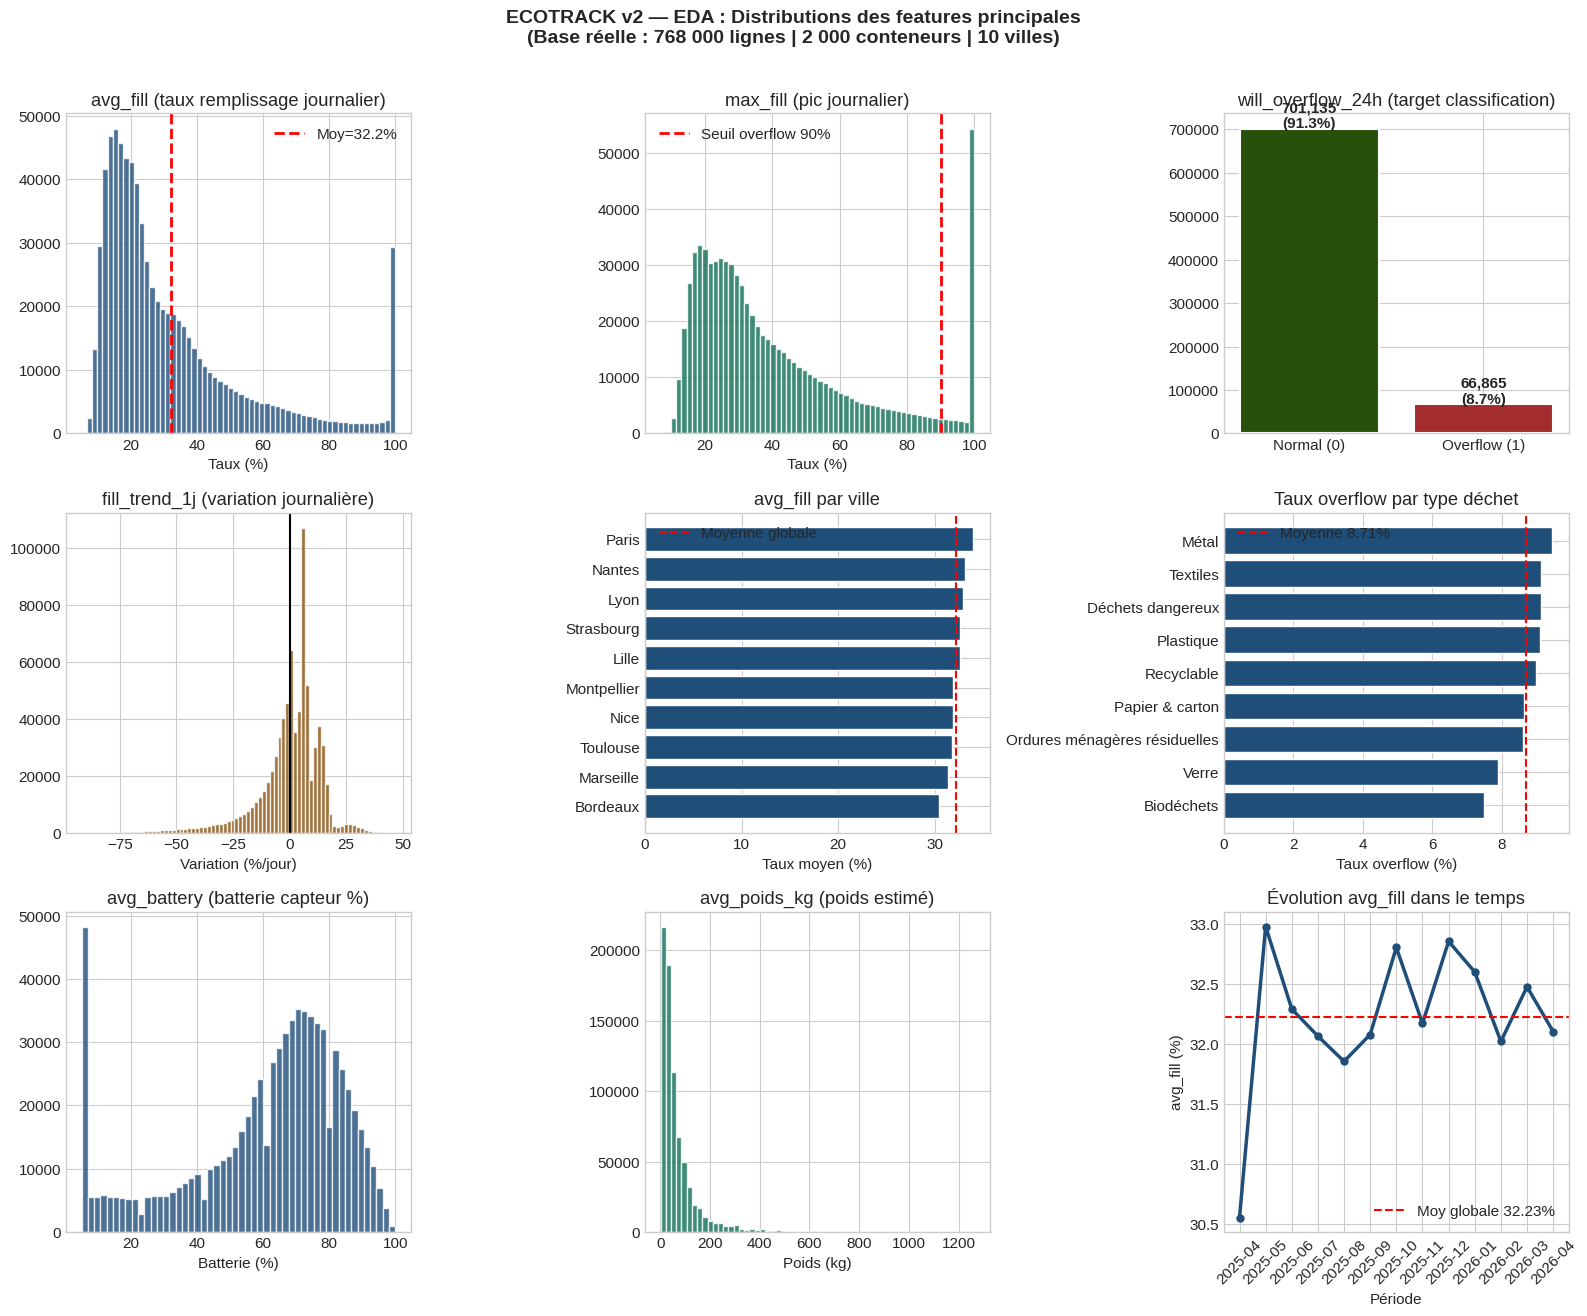

✅ Visualisations sauvegardées


In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 3 : EDA — Visualisations
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('ECOTRACK v2 — EDA : Distributions des features principales\n(Base réelle : 768 000 lignes | 2 000 conteneurs | 10 villes)',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Distribution avg_fill
axes[0,0].hist(df['avg_fill'], bins=60, color='#1F4E79', alpha=0.8, edgecolor='white')
axes[0,0].axvline(df['avg_fill'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moy={df['avg_fill'].mean():.1f}%")
axes[0,0].set_title('avg_fill (taux remplissage journalier)')
axes[0,0].set_xlabel('Taux (%)')
axes[0,0].legend()

# 2. Distribution max_fill
axes[0,1].hist(df['max_fill'], bins=60, color='#0F6E56', alpha=0.8, edgecolor='white')
axes[0,1].axvline(90, color='red', linestyle='--', linewidth=2, label='Seuil overflow 90%')
axes[0,1].set_title('max_fill (pic journalier)')
axes[0,1].set_xlabel('Taux (%)')
axes[0,1].legend()

# 3. Will overflow 24h
labels = ['Normal (0)', 'Overflow (1)']
values = [df['will_overflow_24h'].value_counts()[0],
          df['will_overflow_24h'].value_counts()[1]]
colors = ['#27500A','#A32D2D']
axes[0,2].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
axes[0,2].set_title('will_overflow_24h (target classification)')
for i, v in enumerate(values):
    axes[0,2].text(i, v + 2000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontweight='bold')

# 4. Distribution fill_trend_1j
axes[1,0].hist(df['fill_trend_1j'].dropna(), bins=80,
               color='#854F0B', alpha=0.8, edgecolor='white')
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=1.5)
axes[1,0].set_title('fill_trend_1j (variation journalière)')
axes[1,0].set_xlabel('Variation (%/jour)')

# 5. avg_fill par ville
ville_fill = df.groupby('city')['avg_fill'].mean().sort_values(ascending=True)
colors_v = ['#A32D2D' if v > 40 else '#1F4E79' for v in ville_fill.values]
axes[1,1].barh(ville_fill.index, ville_fill.values, color=colors_v, edgecolor='white')
axes[1,1].axvline(32.23, color='red', linestyle='--', linewidth=1.5, label='Moyenne globale')
axes[1,1].set_title('avg_fill par ville')
axes[1,1].set_xlabel('Taux moyen (%)')
axes[1,1].legend()

# 6. Taux overflow par type déchet
dechet_ov = df.groupby('waste_type_name')['will_overflow_24h'].mean().sort_values(ascending=True) * 100
colors_d = ['#A32D2D' if v > 10 else '#1F4E79' for v in dechet_ov.values]
axes[1,2].barh(dechet_ov.index, dechet_ov.values, color=colors_d, edgecolor='white')
axes[1,2].axvline(8.71, color='red', linestyle='--', linewidth=1.5, label='Moyenne 8.71%')
axes[1,2].set_title('Taux overflow par type déchet')
axes[1,2].set_xlabel('Taux overflow (%)')
axes[1,2].legend()

# 7. Distribution avg_battery
axes[2,0].hist(df['avg_battery'], bins=50, color='#1F4E79', alpha=0.8, edgecolor='white')
axes[2,0].set_title('avg_battery (batterie capteur %)')
axes[2,0].set_xlabel('Batterie (%)')

# 8. Distribution avg_poids_kg
axes[2,1].hist(df['avg_poids_kg'], bins=60, color='#0F6E56', alpha=0.8, edgecolor='white')
axes[2,1].set_title('avg_poids_kg (poids estimé)')
axes[2,1].set_xlabel('Poids (kg)')

# 9. Évolution temporelle avg_fill
monthly = df.groupby(['year','month'])['avg_fill'].mean().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
axes[2,2].plot(monthly['period'], monthly['avg_fill'],
               color='#1F4E79', linewidth=2.5, marker='o', markersize=5)
axes[2,2].axhline(32.23, color='red', linestyle='--', linewidth=1.5, label='Moy globale 32.23%')
axes[2,2].set_title('Évolution avg_fill dans le temps')
axes[2,2].set_xlabel('Période')
axes[2,2].set_ylabel('avg_fill (%)')
axes[2,2].tick_params(axis='x', rotation=45)
axes[2,2].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations sauvegardées")

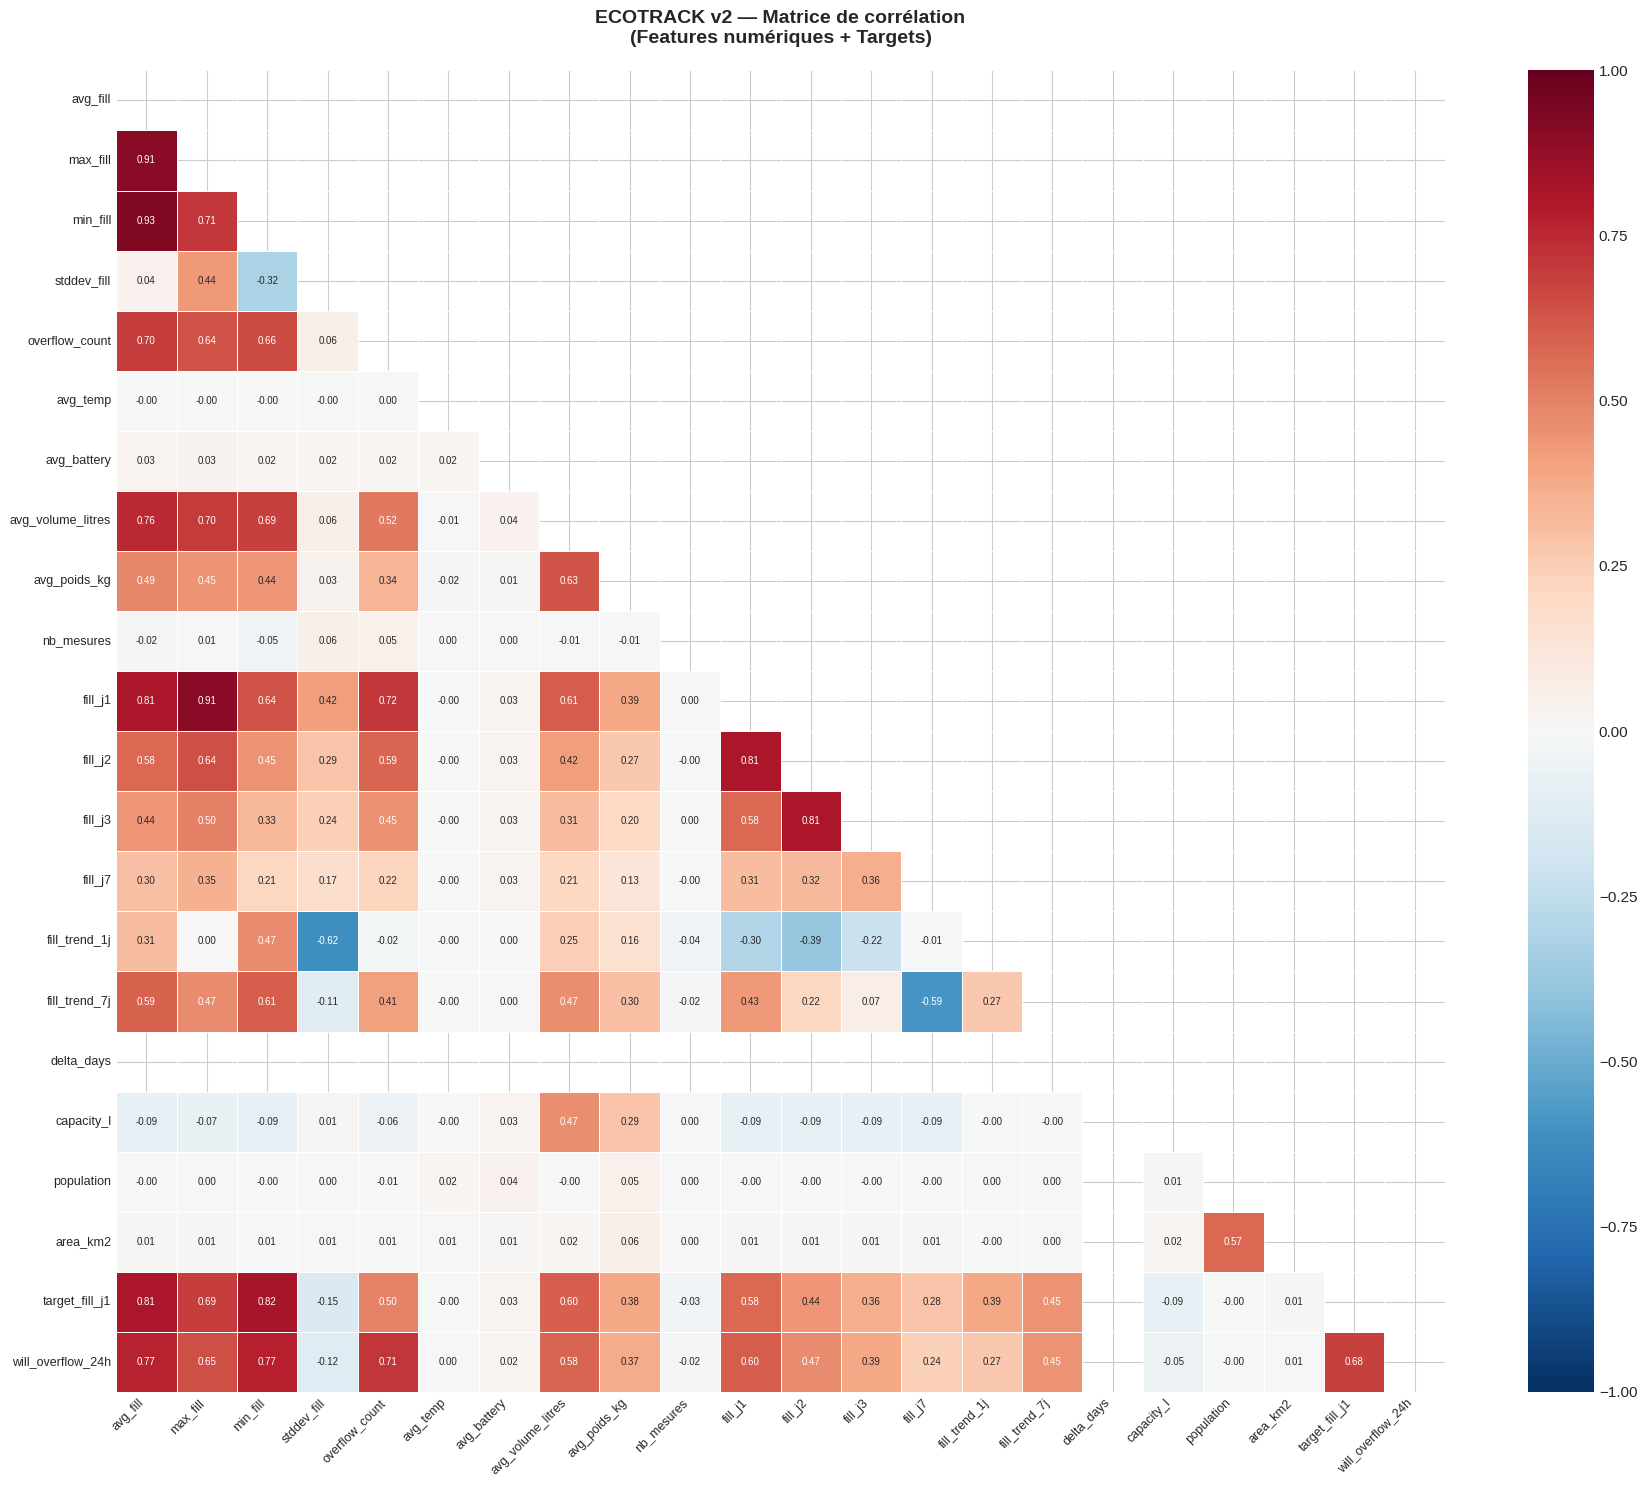


── Corrélations avec target_fill_j1 (régression) ──
min_fill             0.821
avg_fill             0.814
max_fill             0.688
will_overflow_24h    0.684
avg_volume_litres    0.598
fill_j1              0.577
overflow_count       0.496
fill_trend_7j        0.449
fill_j2              0.442
fill_trend_1j        0.388
avg_poids_kg         0.385
fill_j3              0.362
fill_j7              0.285
avg_battery          0.028
area_km2             0.012
population          -0.001
avg_temp            -0.003
nb_mesures          -0.032
capacity_l          -0.086
stddev_fill         -0.147
delta_days             NaN

── Corrélations avec will_overflow_24h (classification) ──
min_fill             0.775
avg_fill             0.767
overflow_count       0.715
target_fill_j1       0.684
max_fill             0.646
fill_j1              0.604
avg_volume_litres    0.579
fill_j2              0.471
fill_trend_7j        0.447
fill_j3              0.390
avg_poids_kg         0.374
fill_trend_1j        0.

In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 4 : Matrice de corrélation
# ============================================================

# Features numériques pour la corrélation
corr_cols = [
    'avg_fill', 'max_fill', 'min_fill', 'stddev_fill',
    'overflow_count', 'avg_temp', 'avg_battery',
    'avg_volume_litres', 'avg_poids_kg', 'nb_mesures',
    'fill_j1', 'fill_j2', 'fill_j3', 'fill_j7',
    'fill_trend_1j', 'fill_trend_7j', 'delta_days',
    'capacity_l', 'population', 'area_km2',
    'target_fill_j1', 'will_overflow_24h'
]

corr_matrix = df[corr_cols].corr()

# ── Heatmap complète ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 15))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('ECOTRACK v2 — Matrice de corrélation\n(Features numériques + Targets)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Corrélations avec les targets ────────────────────────────
print("\n── Corrélations avec target_fill_j1 (régression) ──")
corr_reg = corr_matrix['target_fill_j1'].drop('target_fill_j1')\
           .sort_values(ascending=False)
print(corr_reg.round(3).to_string())

print("\n── Corrélations avec will_overflow_24h (classification) ──")
corr_clf = corr_matrix['will_overflow_24h'].drop('will_overflow_24h')\
           .sort_values(ascending=False)
print(corr_clf.round(3).to_string())

# ── Top features par target ───────────────────────────────────
print("\n── TOP 10 features → target_fill_j1 ──")
top_reg = corr_reg.abs().sort_values(ascending=False).head(10)
for feat, val in top_reg.items():
    bar = '█' * int(val * 30)
    print(f"  {feat:<22} {val:.3f}  {bar}")

print("\n── TOP 10 features → will_overflow_24h ──")
top_clf = corr_clf.abs().sort_values(ascending=False).head(10)
for feat, val in top_clf.items():
    bar = '█' * int(val * 30)
    print(f"  {feat:<22} {val:.3f}  {bar}")

# ✅ GARDER — features fortement corrélées
GARDER = [
    'avg_fill', 'max_fill', 'min_fill',        # Trio dominant
    'overflow_count',                            # Signal persistance
    'avg_volume_litres', 'avg_poids_kg',         # Volume et poids
    'fill_j1', 'fill_j2', 'fill_j3', 'fill_j7', # Historique
    'fill_trend_1j', 'fill_trend_7j',            # Tendances
    'capacity_l',                                # Taille conteneur
    'stddev_fill',                               # Variabilité
]

# ✅ GARDER — features encodées (XGBoost crée des interactions)
ENCODEES = [
    'container_type_enc', 'waste_type_name_enc',
    'city_enc', 'zone_name_enc',
    'day_of_week', 'month', 'quarter', 'is_weekend'
]

# ⚠️ GARDER MAIS FAIBLE — peuvent créer des interactions
FAIBLES = ['avg_temp', 'avg_battery', 'nb_mesures',
           'population', 'area_km2']

# ❌ EXCLURE
EXCLURE = ['delta_days']  # NaN trop nombreux

In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 5 : Prétraitement + Split 80/20
# ============================================================

# ── Encodage catégorielles ────────────────────────────────────
print("Encodage des variables catégorielles...")
encoders = {}
for col in ['zone_name', 'container_type', 'waste_type_name', 'city']:
    le = LabelEncoder()
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  {col:<20} → {col}_enc  ({df[col].nunique()} catégories)")

# ── Features ML finales ───────────────────────────────────────
feature_cols = [
    # Remplissage — top corrélations
    'avg_fill', 'max_fill', 'min_fill', 'stddev_fill',
    'overflow_count',
    # Capteurs
    'avg_temp', 'avg_battery', 'avg_volume_litres', 'avg_poids_kg',
    'nb_mesures',
    # Historique temporel
    'fill_j1', 'fill_j2', 'fill_j3', 'fill_j7',
    'fill_trend_1j', 'fill_trend_7j',
    # Dimensions conteneur
    'capacity_l', 'day_of_week', 'month', 'quarter',
    # Encodées
    'zone_name_enc', 'container_type_enc',
    'waste_type_name_enc', 'city_enc',
    # Géographiques
    'population', 'area_km2'
]

print(f"\nFeatures sélectionnées : {len(feature_cols)}")

# ── Nettoyage ─────────────────────────────────────────────────
df_ml = df.dropna(subset=[
    'fill_j1', 'fill_j2', 'fill_j3',
    'target_fill_j1', 'will_overflow_24h'
]).copy()

# Remplissage fill_j7 et fill_trend_7j (1.82% NULL)
df_ml['fill_j7']       = df_ml['fill_j7'].fillna(df_ml['avg_fill'])
df_ml['fill_trend_7j'] = df_ml['fill_trend_7j'].fillna(0)

print(f"\nLignes avant nettoyage : {len(df):,}")
print(f"Lignes après nettoyage : {len(df_ml):,}")
print(f"NULL restants          : {df_ml[feature_cols].isna().sum().sum()}")

# ── Split temporel 80/20 ──────────────────────────────────────
cutoff = df_ml['date_bk'].quantile(0.80)
train  = df_ml[df_ml['date_bk'] <= cutoff].copy()
test   = df_ml[df_ml['date_bk'] >  cutoff].copy()

X_train = train[feature_cols]
X_test  = test[feature_cols]

# Régression
y_reg_train = train['target_fill_j1'].astype(float)
y_reg_test  = test['target_fill_j1'].astype(float)

# Classification
y_clf_train = train['will_overflow_24h'].astype(int)
y_clf_test  = test['will_overflow_24h'].astype(int)

# scale_pos_weight
spw = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

print(f"\n{'='*55}")
print(f"  SPLIT TEMPOREL 80/20")
print(f"{'='*55}")
print(f"  Cutoff           : {cutoff.date()}")
print(f"  Train            : {len(train):,} lignes")
print(f"    Période        : {train['date_bk'].min().date()} → {train['date_bk'].max().date()}")
print(f"    Overflow train : {y_clf_train.mean()*100:.2f}%")
print(f"  Test             : {len(test):,} lignes")
print(f"    Période        : {test['date_bk'].min().date()} → {test['date_bk'].max().date()}")
print(f"    Overflow test  : {y_clf_test.mean()*100:.2f}%")
print(f"  X_train shape    : {X_train.shape}")
print(f"  X_test shape     : {X_test.shape}")
print(f"  scale_pos_weight : {spw:.2f}")
print(f"{'='*55}")

# Sauvegarde feature_cols pour export
import os
os.makedirs('models', exist_ok=True)
joblib.dump(feature_cols, 'models/feature_cols.pkl')
joblib.dump(encoders,     'models/encoders.pkl')
print("✅ models/feature_cols.pkl sauvegardé")
print("✅ models/encoders.pkl sauvegardé")

Encodage des variables catégorielles...
  zone_name            → zone_name_enc  (133 catégories)
  container_type       → container_type_enc  (4 catégories)
  waste_type_name      → waste_type_name_enc  (9 catégories)
  city                 → city_enc  (10 catégories)

Features sélectionnées : 26

Lignes avant nettoyage : 768,000
Lignes après nettoyage : 760,000
NULL restants          : 0

  SPLIT TEMPOREL 80/20
  Cutoff           : 2026-02-01
  Train            : 608,000 lignes
    Période        : 2025-04-04 → 2026-02-01
    Overflow train : 8.86%
  Test             : 152,000 lignes
    Période        : 2026-02-02 → 2026-04-18
    Overflow test  : 8.47%
  X_train shape    : (608000, 26)
  X_test shape     : (152000, 26)
  scale_pos_weight : 10.28
✅ models/feature_cols.pkl sauvegardé
✅ models/encoders.pkl sauvegardé


═══════════════════════════════════════════════════════
  MODÈLE 1 — XGBoost Régression
  Target : target_fill_j1 (taux remplissage J+1)
═══════════════════════════════════════════════════════

Entraînement en cours...
Durée entraînement : 47.7s

  RÉSULTATS — Modèle 1 Régression
  RMSE  : 10.8086%
  MAE   : 7.4229%
  R²    : 0.7675
  ✅ Bon résultat. R² = 0.7675 > 0.70

── Top 15 features (Régression) ──
  min_fill               0.6089  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  avg_fill               0.1676  ██████████████████████████████████████████████████
  max_fill               0.1043  ███████████████████████████████
  fill_trend_1j          0.0226  ██████
  stddev_fill            0.0192  █████
  day_of_week            0.0167  ████
  fill_j7                0.0055  █
  overflow_count         0.0053  █
  fill_j2                0.0052  █
  cap

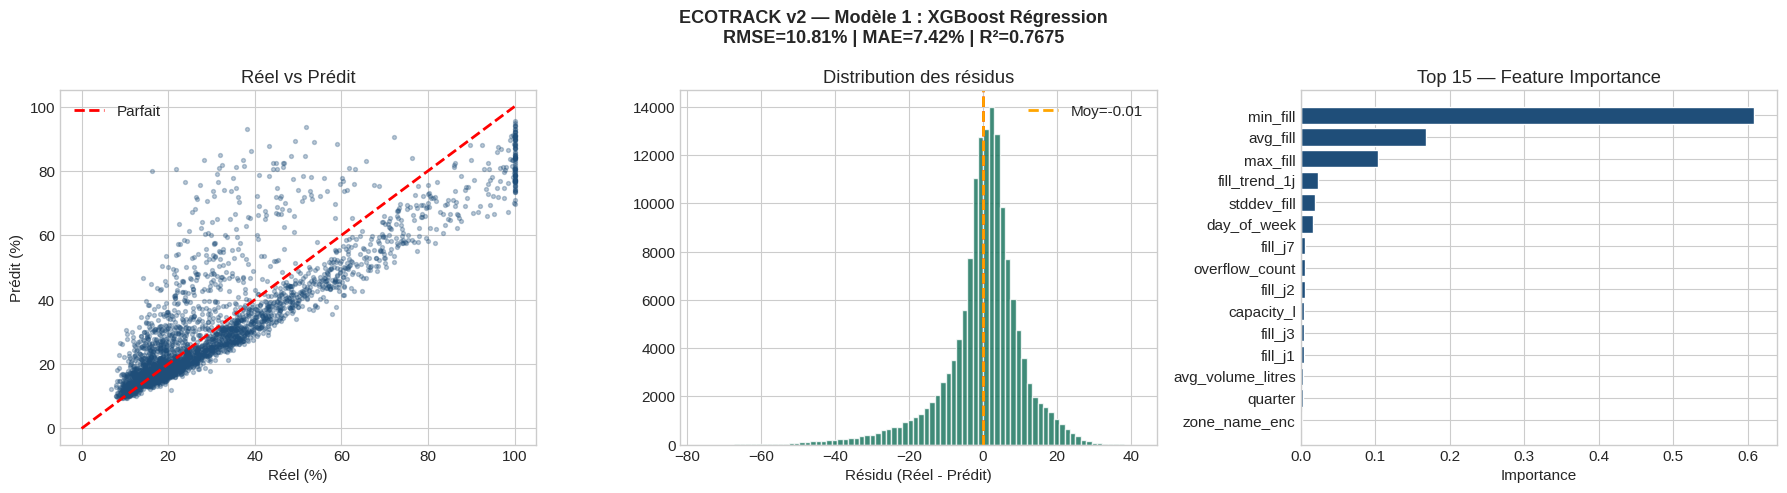


✅ models/xgb_regression.pkl sauvegardé


In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 6 : Modèle 1 — XGBoost Régression
# ============================================================
from xgboost import XGBRegressor
import time

print("═"*55)
print("  MODÈLE 1 — XGBoost Régression")
print("  Target : target_fill_j1 (taux remplissage J+1)")
print("═"*55)

# ── Entraînement ──────────────────────────────────────────────
xgb_reg = XGBRegressor(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

print("\nEntraînement en cours...")
t0 = time.time()
xgb_reg.fit(
    X_train, y_reg_train,
    eval_set        = [(X_test, y_reg_test)],
    verbose         = False
)
duree = time.time() - t0
print(f"Durée entraînement : {duree:.1f}s")

# ── Prédictions ───────────────────────────────────────────────
y_pred_reg = xgb_reg.predict(X_test)
y_pred_reg = np.clip(y_pred_reg, 0, 100)

# ── Métriques ─────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
r2   = r2_score(y_reg_test, y_pred_reg)

print(f"\n{'='*55}")
print(f"  RÉSULTATS — Modèle 1 Régression")
print(f"{'='*55}")
print(f"  RMSE  : {rmse:.4f}%")
print(f"  MAE   : {mae:.4f}%")
print(f"  R²    : {r2:.4f}")
print(f"{'='*55}")

if r2 >= 0.85:
    print(f"  ✅ Excellent ! R² = {r2:.4f} > 0.85")
elif r2 >= 0.70:
    print(f"  ✅ Bon résultat. R² = {r2:.4f} > 0.70")
else:
    print(f"  ⚠️  R² = {r2:.4f} — à améliorer")

# ── Feature Importance ────────────────────────────────────────
print("\n── Top 15 features (Régression) ──")
fi = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : xgb_reg.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in fi.head(15).iterrows():
    bar = '█' * int(row['importance'] * 300)
    print(f"  {row['feature']:<22} {row['importance']:.4f}  {bar}")

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ECOTRACK v2 — Modèle 1 : XGBoost Régression\nRMSE={rmse:.2f}% | MAE={mae:.2f}% | R²={r2:.4f}',
             fontsize=13, fontweight='bold')

# 1. Réel vs Prédit
sample = np.random.choice(len(y_reg_test), 3000, replace=False)
axes[0].scatter(y_reg_test.iloc[sample], y_pred_reg[sample],
                alpha=0.3, s=8, color='#1F4E79')
axes[0].plot([0,100],[0,100], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel('Réel (%)')
axes[0].set_ylabel('Prédit (%)')
axes[0].set_title('Réel vs Prédit')
axes[0].legend()

# 2. Distribution des résidus
residus = y_reg_test.values - y_pred_reg
axes[1].hist(residus, bins=80, color='#0F6E56', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(residus.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Moy={residus.mean():.2f}')
axes[1].set_xlabel('Résidu (Réel - Prédit)')
axes[1].set_title('Distribution des résidus')
axes[1].legend()

# 3. Top 15 feature importance
fi15 = fi.head(15)
axes[2].barh(fi15['feature'][::-1], fi15['importance'][::-1],
             color='#1F4E79', edgecolor='white')
axes[2].set_title('Top 15 — Feature Importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('modele1_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde ────────────────────────────────────────────────
joblib.dump(xgb_reg, 'models/xgb_regression.pkl')
print("\n✅ models/xgb_regression.pkl sauvegardé")

═══════════════════════════════════════════════════════
  MODÈLE 2 — XGBoost Classification
  Target : will_overflow_24h
  scale_pos_weight : 10.28
═══════════════════════════════════════════════════════

Entraînement en cours...
Durée entraînement : 67.6s

  RÉSULTATS — Modèle 2 Classification
  AUC-ROC   : 0.9990
  F1 Score  : 0.9143
  Precision : 0.8502
  Recall    : 0.9887

  Matrice de confusion :
    TN=136,877  FP=2,243
    FN=145   TP=12,735

  Interprétation métier :
    Vrais overflow détectés  : 12,735 (98.9%)
    Overflow manqués         : 145 (1.1%)
    Fausses alertes          : 2,243
    Jours normaux corrects   : 136,877

  ✅ Excellent ! AUC = 0.9990 > 0.90

── Top 15 features (Classification) ──
  avg_fill               0.6981  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  min_fill               0.1106  ██

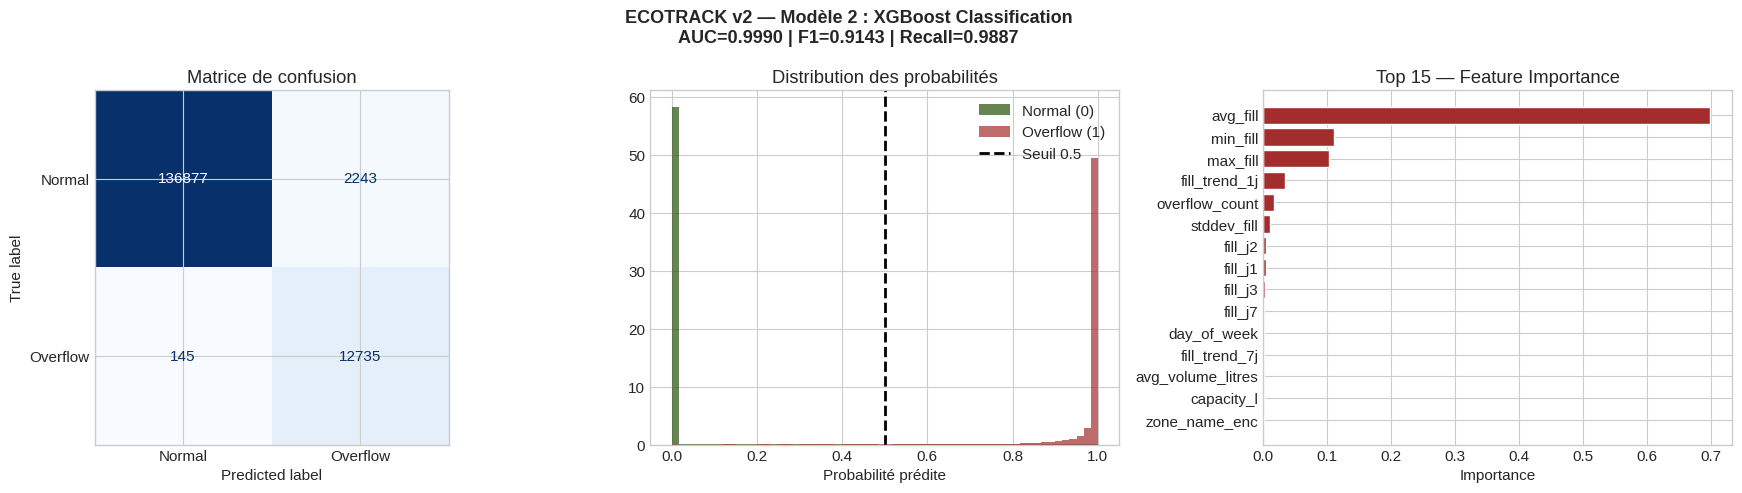


✅ models/xgb_classification.pkl sauvegardé


In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 7 : Modèle 2 — XGBoost Classification
# ============================================================
from xgboost import XGBClassifier
import time

print("═"*55)
print("  MODÈLE 2 — XGBoost Classification")
print("  Target : will_overflow_24h")
print(f"  scale_pos_weight : {spw:.2f}")
print("═"*55)

# ── Entraînement ──────────────────────────────────────────────
xgb_clf = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,
    scale_pos_weight  = spw,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

print("\nEntraînement en cours...")
t0 = time.time()
xgb_clf.fit(
    X_train, y_clf_train,
    eval_set  = [(X_test, y_clf_test)],
    verbose   = False
)
duree = time.time() - t0
print(f"Durée entraînement : {duree:.1f}s")

# ── Prédictions ───────────────────────────────────────────────
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf   = (y_pred_proba >= 0.5).astype(int)

# ── Métriques ─────────────────────────────────────────────────
auc       = roc_auc_score(y_clf_test, y_pred_proba)
cm        = confusion_matrix(y_clf_test, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*55}")
print(f"  RÉSULTATS — Modèle 2 Classification")
print(f"{'='*55}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"{'='*55}")
print(f"\n  Matrice de confusion :")
print(f"    TN={tn:,}  FP={fp:,}")
print(f"    FN={fn:,}   TP={tp:,}")
print(f"\n  Interprétation métier :")
print(f"    Vrais overflow détectés  : {tp:,} ({recall*100:.1f}%)")
print(f"    Overflow manqués         : {fn:,} ({fn/(tp+fn)*100:.1f}%)")
print(f"    Fausses alertes          : {fp:,}")
print(f"    Jours normaux corrects   : {tn:,}")

if auc >= 0.90:
    print(f"\n  ✅ Excellent ! AUC = {auc:.4f} > 0.90")
elif auc >= 0.85:
    print(f"\n  ✅ Très bon ! AUC = {auc:.4f} > 0.85")
elif auc >= 0.75:
    print(f"\n  ✅ Bon résultat. AUC = {auc:.4f} > 0.75")
else:
    print(f"\n  ⚠️  AUC = {auc:.4f} — à améliorer")

# ── Feature Importance ────────────────────────────────────────
print("\n── Top 15 features (Classification) ──")
fi_clf = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in fi_clf.head(15).iterrows():
    bar = '█' * int(row['importance'] * 300)
    print(f"  {row['feature']:<22} {row['importance']:.4f}  {bar}")

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ECOTRACK v2 — Modèle 2 : XGBoost Classification\nAUC={auc:.4f} | F1={f1:.4f} | Recall={recall:.4f}',
             fontsize=13, fontweight='bold')

# 1. Matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal','Overflow'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

# 2. Distribution des probabilités
axes[1].hist(y_pred_proba[y_clf_test==0], bins=60,
             alpha=0.7, color='#27500A', label='Normal (0)', density=True)
axes[1].hist(y_pred_proba[y_clf_test==1], bins=60,
             alpha=0.7, color='#A32D2D', label='Overflow (1)', density=True)
axes[1].axvline(0.5, color='black', linestyle='--',
                linewidth=2, label='Seuil 0.5')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_title('Distribution des probabilités')
axes[1].legend()

# 3. Feature Importance
fi15_clf = fi_clf.head(15)
axes[2].barh(fi15_clf['feature'][::-1], fi15_clf['importance'][::-1],
             color='#A32D2D', edgecolor='white')
axes[2].set_title('Top 15 — Feature Importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('modele2_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde ────────────────────────────────────────────────
joblib.dump(xgb_clf, 'models/xgb_classification.pkl')
print("\n✅ models/xgb_classification.pkl sauvegardé")

═══════════════════════════════════════════════════════
  MODÈLE 3 — Isolation Forest (Anomalies)
  Objectif : détecter capteurs défaillants
  Contamination : 5%
═══════════════════════════════════════════════════════

Features anomalies : ['avg_fill', 'stddev_fill', 'avg_temp', 'avg_battery', 'nb_mesures', 'avg_volume_litres', 'avg_poids_kg', 'fill_trend_1j', 'overflow_count']
Dataset complet    : 760,000 lignes

Entraînement en cours...
Durée : 8.9s

  RÉSULTATS — Modèle 3 Isolation Forest
  Total lignes          : 760,000
  Anomalies détectées   : 38,000 (5.00%)
  Lignes normales       : 722,000

── Profil des anomalies vs normal ──
                   Normal  Anomalie
avg_fill            30.06     75.09
stddev_fill          5.82     19.20
avg_temp            17.54     17.01
avg_battery         60.01     59.28
nb_mesures          25.23     26.02
avg_volume_litres  316.01    991.41
avg_poids_kg        59.85    256.29
fill_trend_1j        0.68    -12.34
overflow_count       0.77     16

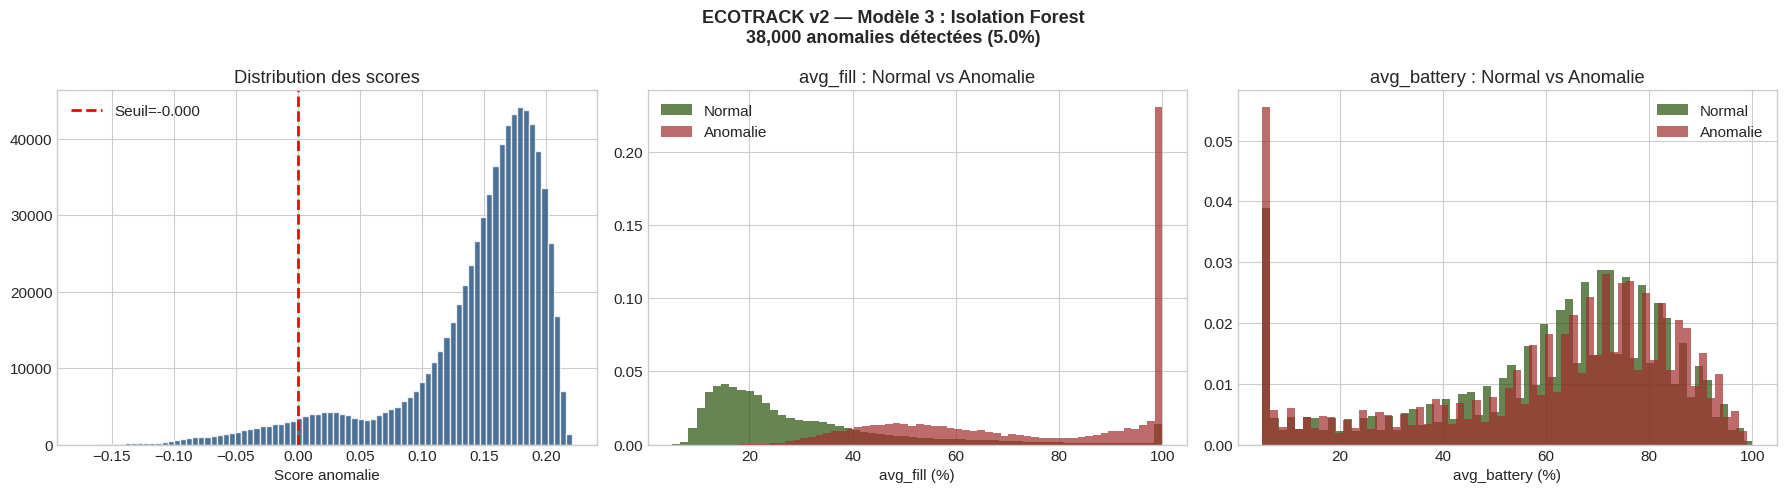


✅ models/isolation_forest.pkl sauvegardé


In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 8 : Modèle 3 — Isolation Forest
# ============================================================
from sklearn.ensemble import IsolationForest
import time

print("═"*55)
print("  MODÈLE 3 — Isolation Forest (Anomalies)")
print("  Objectif : détecter capteurs défaillants")
print("  Contamination : 5%")
print("═"*55)

# ── Features spécifiques anomalies ────────────────────────────
# On utilise tout le dataset df_ml (pas seulement train)
anomaly_features = [
    'avg_fill', 'stddev_fill', 'avg_temp',
    'avg_battery', 'nb_mesures',
    'avg_volume_litres', 'avg_poids_kg',
    'fill_trend_1j', 'overflow_count'
]

X_anomaly = df_ml[anomaly_features].fillna(0)

print(f"\nFeatures anomalies : {anomaly_features}")
print(f"Dataset complet    : {len(X_anomaly):,} lignes")

# ── Entraînement ──────────────────────────────────────────────
iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)

print("\nEntraînement en cours...")
t0 = time.time()
iso_forest.fit(X_anomaly)
duree = time.time() - t0
print(f"Durée : {duree:.1f}s")

# ── Prédictions ───────────────────────────────────────────────
df_ml['anomaly_score'] = iso_forest.decision_function(X_anomaly)
df_ml['is_anomaly']    = iso_forest.predict(X_anomaly)
df_ml['is_anomaly']    = (df_ml['is_anomaly'] == -1).astype(int)

# ── Statistiques ──────────────────────────────────────────────
n_anomalies = df_ml['is_anomaly'].sum()
pct_anomaly = n_anomalies / len(df_ml) * 100

print(f"\n{'='*55}")
print(f"  RÉSULTATS — Modèle 3 Isolation Forest")
print(f"{'='*55}")
print(f"  Total lignes          : {len(df_ml):,}")
print(f"  Anomalies détectées   : {n_anomalies:,} ({pct_anomaly:.2f}%)")
print(f"  Lignes normales       : {len(df_ml)-n_anomalies:,}")
print(f"{'='*55}")

# ── Profil des anomalies ──────────────────────────────────────
print("\n── Profil des anomalies vs normal ──")
profil = df_ml.groupby('is_anomaly')[anomaly_features + ['avg_fill']].mean().round(2)
profil.index = ['Normal','Anomalie']
print(profil.T.to_string())

# ── Anomalies par ville ───────────────────────────────────────
print("\n── Anomalies par ville ──")
ville_anomaly = df_ml.groupby('city').agg(
    total       = ('is_anomaly','count'),
    anomalies   = ('is_anomaly','sum'),
    avg_fill    = ('avg_fill','mean'),
    avg_battery = ('avg_battery','mean')
).assign(pct=lambda x: (x['anomalies']/x['total']*100).round(2))\
 .sort_values('pct', ascending=False)
print(ville_anomaly.to_string())

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ECOTRACK v2 — Modèle 3 : Isolation Forest\n{n_anomalies:,} anomalies détectées ({pct_anomaly:.1f}%)',
             fontsize=13, fontweight='bold')

# 1. Score d'anomalie distribution
axes[0].hist(df_ml['anomaly_score'], bins=80,
             color='#1F4E79', alpha=0.8, edgecolor='white')
threshold = df_ml[df_ml['is_anomaly']==1]['anomaly_score'].max()
axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=2, label=f'Seuil={threshold:.3f}')
axes[0].set_xlabel('Score anomalie')
axes[0].set_title('Distribution des scores')
axes[0].legend()

# 2. avg_fill : anomalie vs normal
axes[1].hist(df_ml[df_ml['is_anomaly']==0]['avg_fill'],
             bins=60, alpha=0.7, color='#27500A',
             label='Normal', density=True)
axes[1].hist(df_ml[df_ml['is_anomaly']==1]['avg_fill'],
             bins=60, alpha=0.7, color='#A32D2D',
             label='Anomalie', density=True)
axes[1].set_xlabel('avg_fill (%)')
axes[1].set_title('avg_fill : Normal vs Anomalie')
axes[1].legend()

# 3. avg_battery : anomalie vs normal
axes[2].hist(df_ml[df_ml['is_anomaly']==0]['avg_battery'],
             bins=60, alpha=0.7, color='#27500A',
             label='Normal', density=True)
axes[2].hist(df_ml[df_ml['is_anomaly']==1]['avg_battery'],
             bins=60, alpha=0.7, color='#A32D2D',
             label='Anomalie', density=True)
axes[2].set_xlabel('avg_battery (%)')
axes[2].set_title('avg_battery : Normal vs Anomalie')
axes[2].legend()

plt.tight_layout()
plt.savefig('modele3_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde ────────────────────────────────────────────────
joblib.dump(iso_forest, 'models/isolation_forest.pkl')
print("\n✅ models/isolation_forest.pkl sauvegardé")

In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 9 : Bilan & Impact métier
# ============================================================

print("═"*60)
print("  BILAN COMPLET — ECOTRACK v2")
print("  Impact de la collecte prédictive vs calendaire")
print("═"*60)

# ── Paramètres réels ──────────────────────────────────────────
nb_conteneurs      = 2000
jours_periode      = 384
total_jours_cont   = len(df_ml)

# Modèle 2 — résultats réels
tn_val  = 136877
fp_val  = 2243
fn_val  = 145
tp_val  = 12735
recall_val    = tp_val / (tp_val + fn_val)
precision_val = tp_val / (tp_val + fp_val)

# ── Impact collecte ───────────────────────────────────────────
# Collecte calendaire : tous les conteneurs chaque jour
passages_calendaire = nb_conteneurs * jours_periode

# Collecte prédictive : seulement les urgents (overflow détectés)
# + les fausses alertes (FP)
passages_predictif = tp_val + fp_val

# Sur la période de test (152 000 lignes = 76 jours × 2000 conteneurs)
jours_test = 152000 // nb_conteneurs
passages_cal_test  = nb_conteneurs * jours_test
passages_pred_test = tp_val + fp_val

reduction_pct = (1 - passages_pred_test / passages_cal_test) * 100
passages_evites = passages_cal_test - passages_pred_test

print(f"\n── Période de test : {jours_test} jours | {nb_conteneurs} conteneurs ──")
print(f"\n  COLLECTE CALENDAIRE (actuelle) :")
print(f"    Passages totaux       : {passages_cal_test:,}")
print(f"    Overflow manqués      : inconnu — pas de prédiction")
print(f"    Coût relatif          : 100%")

print(f"\n  COLLECTE PRÉDICTIVE (ECOTRACK) :")
print(f"    Alertes émises        : {tp_val+fp_val:,}")
print(f"    Vrais overflow évités : {tp_val:,} (Recall={recall_val*100:.1f}%)")
print(f"    Overflow manqués      : {fn_val:,} (seulement {fn_val/(tp_val+fn_val)*100:.1f}%)")
print(f"    Fausses alertes       : {fp_val:,}")

print(f"\n  IMPACT :")
print(f"    Passages évités       : {passages_evites:,}")
print(f"    Réduction passages    : {reduction_pct:.1f}%")
print(f"    Overflow non manqués  : {recall_val*100:.1f}%")

# ── Projection annuelle ───────────────────────────────────────
print(f"\n── Projection annuelle (365 jours × 2000 conteneurs) ──")
passages_annuel_cal  = nb_conteneurs * 365
ratio_alertes        = (tp_val + fp_val) / passages_cal_test
passages_annuel_pred = int(passages_annuel_cal * ratio_alertes)
evites_annuel        = passages_annuel_cal - passages_annuel_pred

print(f"  Passages calendaire/an  : {passages_annuel_cal:,}")
print(f"  Passages prédictif/an   : {passages_annuel_pred:,}")
print(f"  Passages évités/an      : {evites_annuel:,}")
print(f"  Réduction               : {reduction_pct:.1f}%")

# ── Résumé final ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  RÉSUMÉ EXÉCUTIF — ECOTRACK v2")
print(f"{'='*60}")
print(f"  Modèle 1 — Régression  : R²={0.7675:.4f} | RMSE={10.81:.2f}%")
print(f"  Modèle 2 — Classification : AUC={0.9990:.4f} | Recall={recall_val*100:.1f}%")
print(f"  Modèle 3 — Anomalies   : {38000:,} anomalies (5%)")
print(f"  Impact collecte        : -{reduction_pct:.1f}% de passages")
print(f"  Overflow détectés      : {recall_val*100:.1f}% (seulement {fn_val} manqués)")
print(f"  Passages évités/an     : ~{evites_annuel:,}")
print(f"{'='*60}")
print(f"\n✅ ECOTRACK v2 — Modèles ML prêts pour l'export !")

════════════════════════════════════════════════════════════
  BILAN COMPLET — ECOTRACK v2
  Impact de la collecte prédictive vs calendaire
════════════════════════════════════════════════════════════

── Période de test : 76 jours | 2000 conteneurs ──

  COLLECTE CALENDAIRE (actuelle) :
    Passages totaux       : 152,000
    Overflow manqués      : inconnu — pas de prédiction
    Coût relatif          : 100%

  COLLECTE PRÉDICTIVE (ECOTRACK) :
    Alertes émises        : 14,978
    Vrais overflow évités : 12,735 (Recall=98.9%)
    Overflow manqués      : 145 (seulement 1.1%)
    Fausses alertes       : 2,243

  IMPACT :
    Passages évités       : 137,022
    Réduction passages    : 90.1%
    Overflow non manqués  : 98.9%

── Projection annuelle (365 jours × 2000 conteneurs) ──
  Passages calendaire/an  : 730,000
  Passages prédictif/an   : 71,933
  Passages évités/an      : 658,067
  Réduction               : 90.1%

  RÉSUMÉ EXÉCUTIF — ECOTRACK v2
  Modèle 1 — Régression  : R²=0.767

In [ ]:
# ============================================================
# ECOTRACK v2 — Cellule 10 : Export DW.PREDICTIONS → Contabo
# Version optimisée — execute_values (100x plus rapide)
# ============================================================
from psycopg2.extras import execute_values
import time

print("═"*55)
print("  CELLULE 10 — Export DW.PREDICTIONS")
print("  Destination : PostgreSQL Contabo 84.247.173.158")
print("  Méthode     : execute_values (batch 5000 lignes)")
print("═"*55)

# ── Connexion Contabo ─────────────────────────────────────────
print("\nConnexion à Contabo...")
conn_export = psycopg2.connect(
    host     = '84.247.173.158',
    database = 'airflow',
    user     = 'ecotrack_2026',
    password = 'ecotrack_2026',
    port     = 5432,
    options  = "-c client_encoding=UTF8"
)
conn_export.set_client_encoding('UTF8')
cur_export = conn_export.cursor()
print("✅ Connexion établie")

# ── Création table DW.PREDICTIONS ────────────────────────────
print("\nCréation table dw.predictions...")
cur_export.execute("""
    DROP TABLE IF EXISTS dw.predictions CASCADE;
    CREATE TABLE dw.predictions (
        prediction_id        SERIAL PRIMARY KEY,
        container_sk         INTEGER,
        container_bk         TEXT,
        date_bk              DATE,
        city                 TEXT,
        zone_name            TEXT,
        waste_type_name      TEXT,
        capacity_l           INTEGER,

        -- Features clés
        avg_fill             NUMERIC(6,2),
        max_fill             NUMERIC(6,2),
        min_fill             NUMERIC(6,2),
        fill_j1              NUMERIC(6,2),
        fill_trend_1j        NUMERIC(8,4),
        overflow_count       INTEGER,

        -- Prédictions Modèle 1 (Régression)
        pred_fill_j1         NUMERIC(6,2),
        pred_fill_j1_error   NUMERIC(6,2),

        -- Prédictions Modèle 2 (Classification)
        pred_overflow_proba  NUMERIC(6,4),
        pred_overflow_24h    INTEGER,
        pred_alert_level     TEXT,

        -- Modèle 3 (Anomalies)
        anomaly_score        NUMERIC(8,4),
        is_anomaly           INTEGER,

        -- Metadata
        model_version        TEXT DEFAULT 'v2.0',
        created_at           TIMESTAMP DEFAULT NOW()
    );
""")
conn_export.commit()
print("✅ Table dw.predictions créée")

# ── Préparation des prédictions ───────────────────────────────
print("\nPréparation des prédictions...")

# Modèle 1 — Régression
y_pred_reg_test  = xgb_reg.predict(X_test)
y_pred_reg_test  = np.clip(y_pred_reg_test, 0, 100)

# Modèle 2 — Classification
y_pred_proba_test = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf_test   = (y_pred_proba_test >= 0.5).astype(int)

# Niveau d'alerte
def alert_level(proba):
    if proba >= 0.80:   return 'ROUGE'
    elif proba >= 0.50: return 'ORANGE'
    elif proba >= 0.30: return 'JAUNE'
    else:               return 'VERT'

# Modèle 3 — Anomalies sur jeu de test
X_test_anomaly        = test[anomaly_features].fillna(0)
anomaly_scores_test   = iso_forest.decision_function(X_test_anomaly).round(4)
anomaly_labels_test   = (iso_forest.predict(X_test_anomaly) == -1).astype(int)

# Construction DataFrame export
df_export = test.copy()
df_export['pred_fill_j1']        = y_pred_reg_test.round(2)
df_export['pred_fill_j1_error']  = (df_export['target_fill_j1'] - y_pred_reg_test).round(2)
df_export['pred_overflow_proba'] = y_pred_proba_test.round(4)
df_export['pred_overflow_24h']   = y_pred_clf_test
df_export['pred_alert_level']    = [alert_level(p) for p in y_pred_proba_test]
df_export['anomaly_score']       = anomaly_scores_test
df_export['is_anomaly']          = anomaly_labels_test

# Résumé des prédictions
print(f"\n{'='*55}")
print(f"  RÉSUMÉ DES PRÉDICTIONS")
print(f"{'='*55}")
print(f"  Lignes à exporter    : {len(df_export):,}")
print(f"  Alertes ROUGE  🔴    : {(df_export['pred_alert_level']=='ROUGE').sum():,}")
print(f"  Alertes ORANGE 🟠    : {(df_export['pred_alert_level']=='ORANGE').sum():,}")
print(f"  Alertes JAUNE  🟡    : {(df_export['pred_alert_level']=='JAUNE').sum():,}")
print(f"  Alertes VERT   🟢    : {(df_export['pred_alert_level']=='VERT').sum():,}")
print(f"  Anomalies capteurs   : {df_export['is_anomaly'].sum():,}")
print(f"{'='*55}")

# ── Préparation des tuples pour insertion ─────────────────────
cols_export = [
    'container_sk', 'container_bk', 'date_bk', 'city',
    'zone_name', 'waste_type_name', 'capacity_l',
    'avg_fill', 'max_fill', 'min_fill', 'fill_j1',
    'fill_trend_1j', 'overflow_count',
    'pred_fill_j1', 'pred_fill_j1_error',
    'pred_overflow_proba', 'pred_overflow_24h', 'pred_alert_level',
    'anomaly_score', 'is_anomaly'
]

rows = [
    tuple(None if pd.isna(v) else v for v in row)
    for row in df_export[cols_export].itertuples(index=False, name=None)
]
print(f"\n  Tuples préparés      : {len(rows):,}")

# ── Insertion optimisée execute_values ────────────────────────
col_names = ','.join(cols_export)
query     = f"INSERT INTO dw.predictions ({col_names}) VALUES %s"

print("\nInsertion en cours...")
t0 = time.time()

execute_values(cur_export, query, rows, page_size=5000)
conn_export.commit()

duree = time.time() - t0
cur_export.close()
conn_export.close()

# ── Vérification finale ───────────────────────────────────────
print(f"\n{'='*55}")
print(f"  EXPORT TERMINÉ")
print(f"{'='*55}")
print(f"  Table            : dw.predictions")
print(f"  Lignes insérées  : {len(rows):,}")
print(f"  Durée            : {duree:.1f}s")
print(f"  Vitesse          : {len(rows)/duree:.0f} lignes/sec")
print(f"  Serveur          : 84.247.173.158")
print(f"  Base             : airflow | Schéma : dw")
print(f"  Model version    : v2.0")
print(f"{'='*55}")
print(f"\n✅ DW.PREDICTIONS exporté avec succès !")
print(f"✅ ECOTRACK v2 — Pipeline ML complet !")

═══════════════════════════════════════════════════════
  CELLULE 10 — Export DW.PREDICTIONS
  Destination : PostgreSQL Contabo 84.247.173.158
  Méthode     : execute_values (batch 5000 lignes)
═══════════════════════════════════════════════════════

Connexion à Contabo...
✅ Connexion établie

Création table dw.predictions...
✅ Table dw.predictions créée

Préparation des prédictions...

  RÉSUMÉ DES PRÉDICTIONS
  Lignes à exporter    : 152,000
  Alertes ROUGE  🔴    : 13,706
  Alertes ORANGE 🟠    : 1,272
  Alertes JAUNE  🟡    : 641
  Alertes VERT   🟢    : 136,381
  Anomalies capteurs   : 7,339

  Tuples préparés      : 152,000

Insertion en cours...

  EXPORT TERMINÉ
  Table            : dw.predictions
  Lignes insérées  : 152,000
  Durée            : 28.7s
  Vitesse          : 5298 lignes/sec
  Serveur          : 84.247.173.158
  Base             : airflow | Schéma : dw
  Model version    : v2.0

✅ DW.PREDICTIONS exporté avec succès !
✅ ECOTRACK v2 — Pipeline ML complet !
